In [10]:
from Tools.analysis_tools import *

### Analysis Notebook for $y_2(t)$ Reconstruction Performance:

In this notebook, we analyze the performance of various networks, emphasizing the differences between models. The primary factors examined are the noise introduced by the $\alpha$ and $\beta$ parameters and the effects of dimensionality reduction.


In [11]:
# Percorso della cartella contenente i file CSV degli encoder
decoder_folder = "Decoder Analysis Data"

# Carica i dati
decoder_data = load_decoder_analysis_data(decoder_folder)

# Order the dataset
config_file = 'decoderDatabase.json'
enriched_data = enrich_analysis_with_config(decoder_data, config_file)

# Visualizza i dati ordinati
print(decoder_data.head())


Caricando dati da: Decoder Analysis Data/30-20,15.csv
Caricando dati da: Decoder Analysis Data/30-20_Noise10,0-2.csv
Caricando dati da: Decoder Analysis Data/30-20,3-1.csv
Caricando dati da: Decoder Analysis Data/30-20,3-2.csv
Caricando dati da: Decoder Analysis Data/30-20,3.csv
Caricando dati da: Decoder Analysis Data/30-20.csv
Caricando dati da: Decoder Analysis Data/30-20_Noise10,0-Deeper.csv
Caricando dati da: Decoder Analysis Data/30-20_Noise10,0.csv
Caricando dati da: Decoder Analysis Data/30-20,5.csv
Caricando dati da: Decoder Analysis Data/30-20,10.csv
Caricando dati da: Decoder Analysis Data/30-20_Noise5,0.csv
Caricando dati da: Decoder Analysis Data/30-20-clone.csv
Totale modelli caricati: 12
          Model Name  Latent Dim  Z1 R2 Mean  Z1 R2 Std  Z1 MSE Mean  \
0           30-20,15           5    0.759338   0.247692     0.015334   
1  30-20_Noise10,0-2           5    0.828909   0.292613     0.010474   
2          30-20,3-1           5    0.930265   0.141216     0.005269   


Use this cell to filter the models you want to analyze.

In [12]:
# Lista dei filtri

'''
filter_type: equals o range
filter_value: valore del parametro (numero o range)
'''

filters = [
    {"param_name": "tau", "filter_type": "equals", "filter_value": 3},
    {"param_name": "beta", "filter_type": "equals", "filter_value": 0}
]

filtered_data = filter_by_config_params(enriched_data, filters,True) # True per visualizzare i dati filtrati
#print(filtered_data)

### Reconstruction Metrics for the projected Hankel Matrices:

In this section, we present various metrics calculated directly from the network's output on the validation dataset.

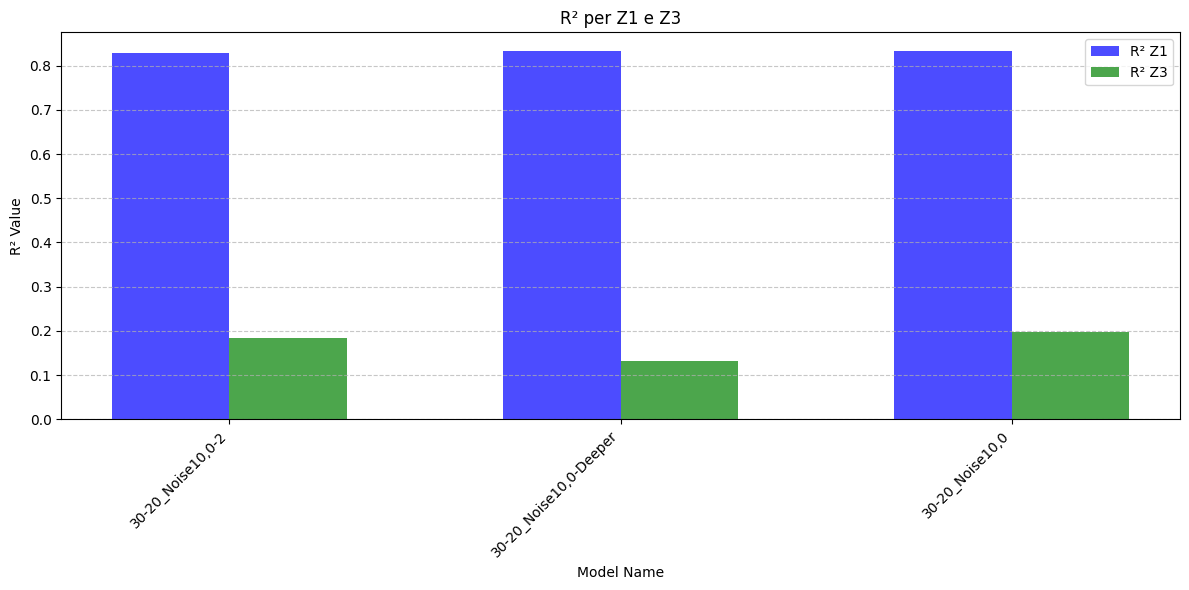

In [13]:
plot_r2_z1_z3(
    data=filtered_data,
    r2_z1_col="Z1 R2 Mean",  # Sostituisci con il nome della colonna corrispondente
    r2_z3_col="Z3 R2 Mean",  # Sostituisci con il nome della colonna corrispondente
    title="R² per Z1 e Z3"
)


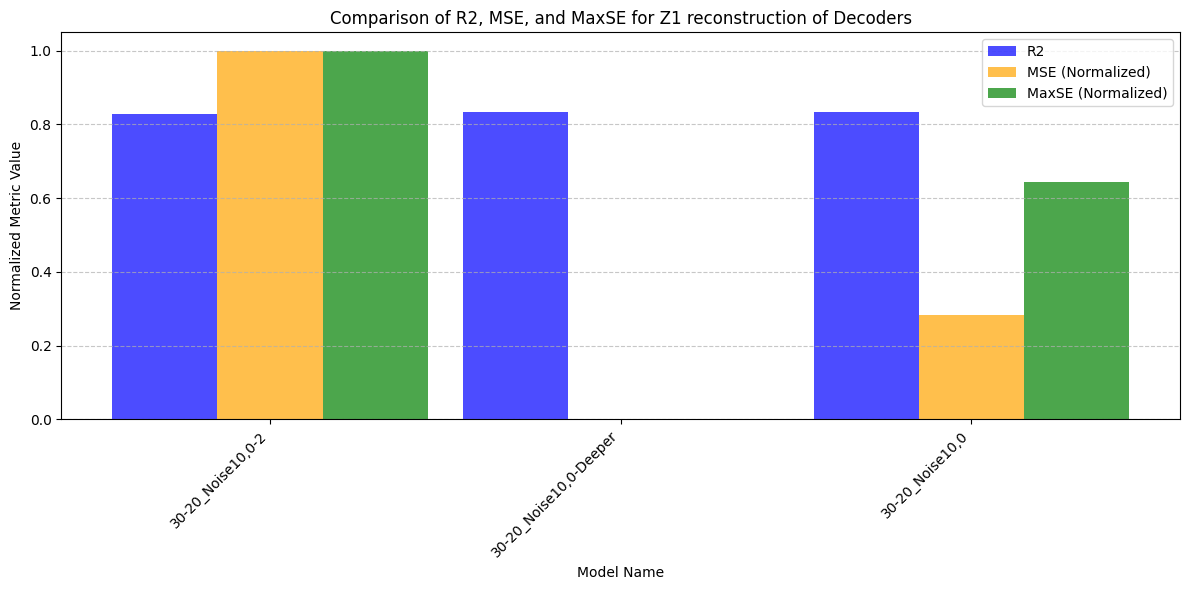

In [14]:
plot_z_metrics(
    data=filtered_data, 
    r2_col="Z1 R2 Mean", 
    mse_col="Z1 MSE Mean", 
    maxse_col="Z1 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Z1 reconstruction of Decoders"
)
#PS: La colonna nulla significa che ha il valore minimo di quella metrica!
# Disattivata normalizzazione di R^2


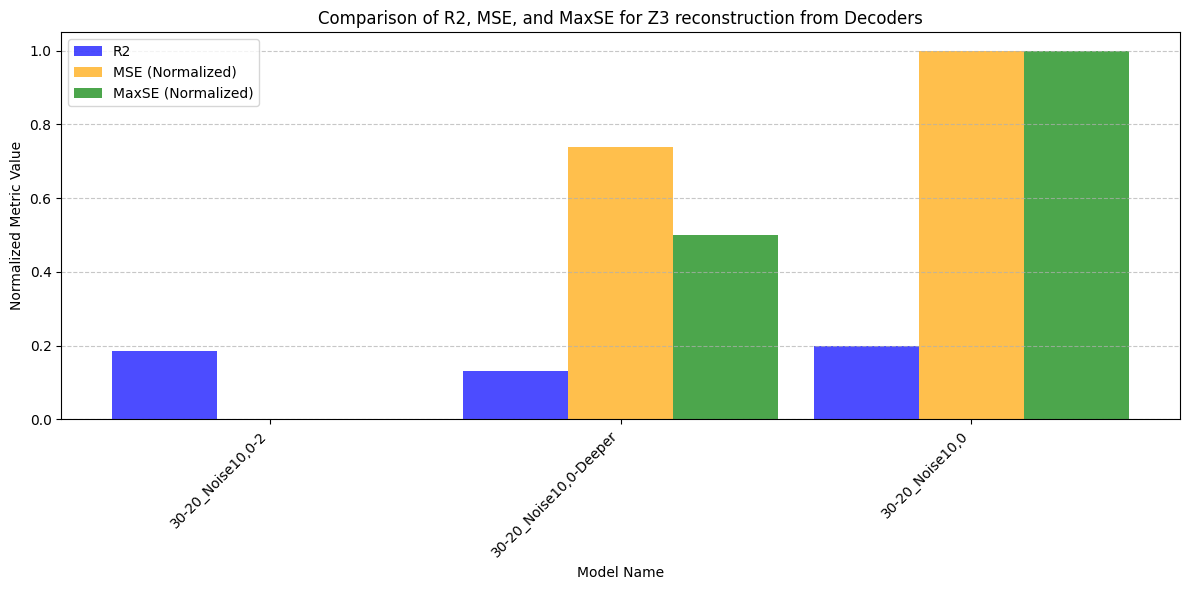

In [15]:
plot_z_metrics(
    data=filtered_data, 
    r2_col="Z3 R2 Mean", 
    mse_col="Z3 MSE Mean", 
    maxse_col="Z3 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Z3 reconstruction from Decoders"
)
#PS: La colonna nulla significa che ha il valore minimo di quella metrica!


In the following graph, the $R^2$ is calculated using post-processed data. The time series is reconstructed by reversing the projection and unfolding the embedding.

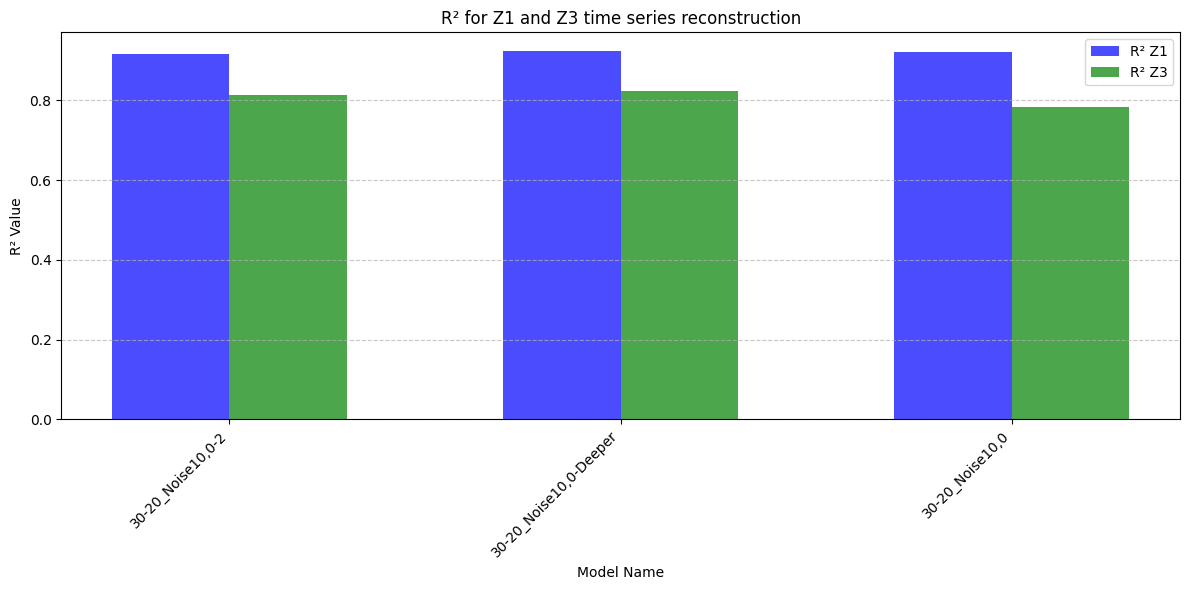

In [16]:
# Supponiamo che il DataFrame sia già caricato in `data`
plot_r2_z1_z3(
    data=filtered_data,
    r2_z1_col="PCA R2 Time Signal Z1",  # Sostituisci con il nome della colonna corrispondente
    r2_z3_col="PCA R2 Time Signal Z3",  # Sostituisci con il nome della colonna corrispondente
    title="R² for Z1 and Z3 time series reconstruction"
)

### Analisi della ricostruzione delle PC:
Sono state calcolate dagli embedding originali le PC tramite PCA ( usando scikit.learn), poi gli output della rete sono stati proiettati lungo le PC dei dati originali e sono stati calcolati gli $R^2$ per componente e la varianza spiegata.

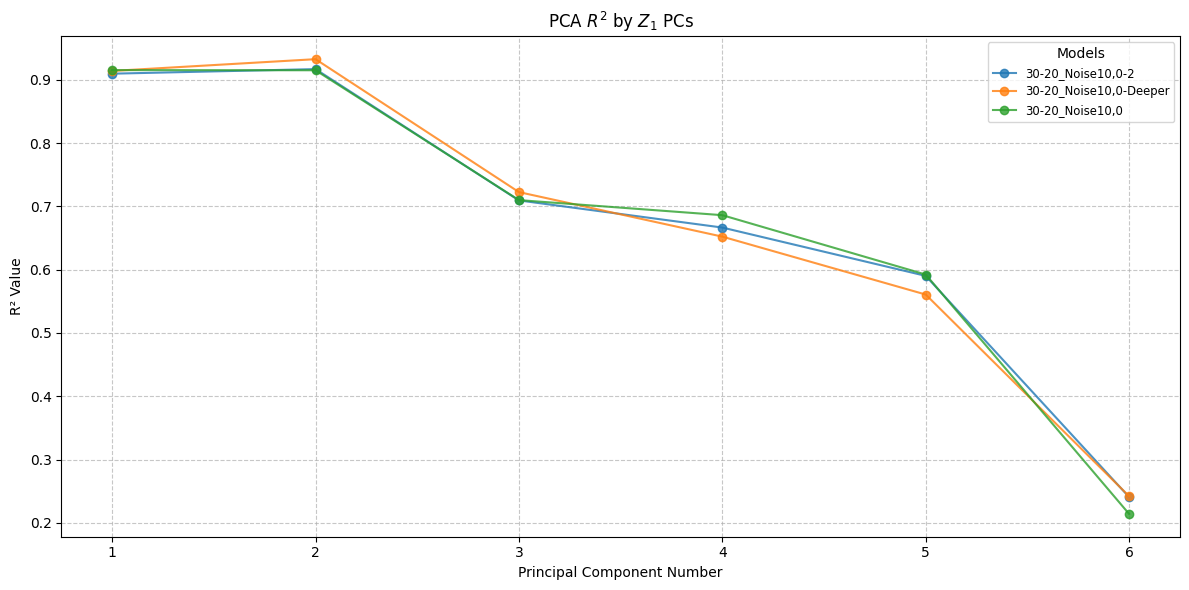

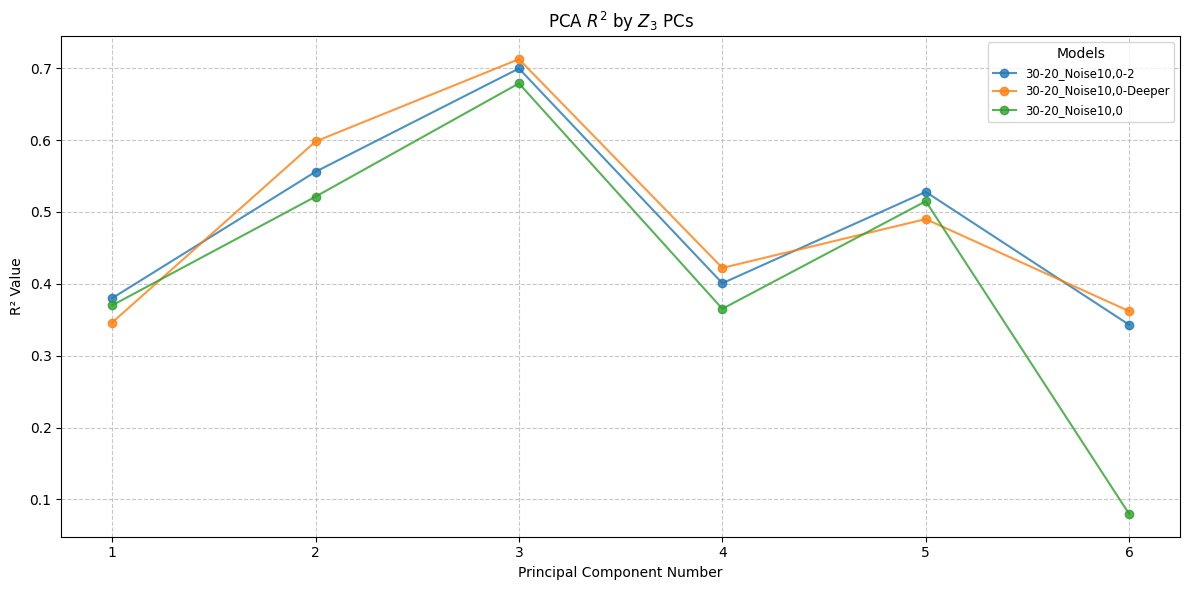

In [17]:
plot_r2_pca(
    data=filtered_data,
    r2_col="PCA R2 Z1 PC",
    variance_col="Varianzce Explained Z1",
    title= f"PCA $R^2$ by $Z_1$ PCs"
)
plot_r2_pca(
    data=filtered_data,
    r2_col="PCA R2 Z3 PC",
    variance_col="Varianzce Explained Z3",
    title= f"PCA $R^2$ by $Z_3$ PCs"
)

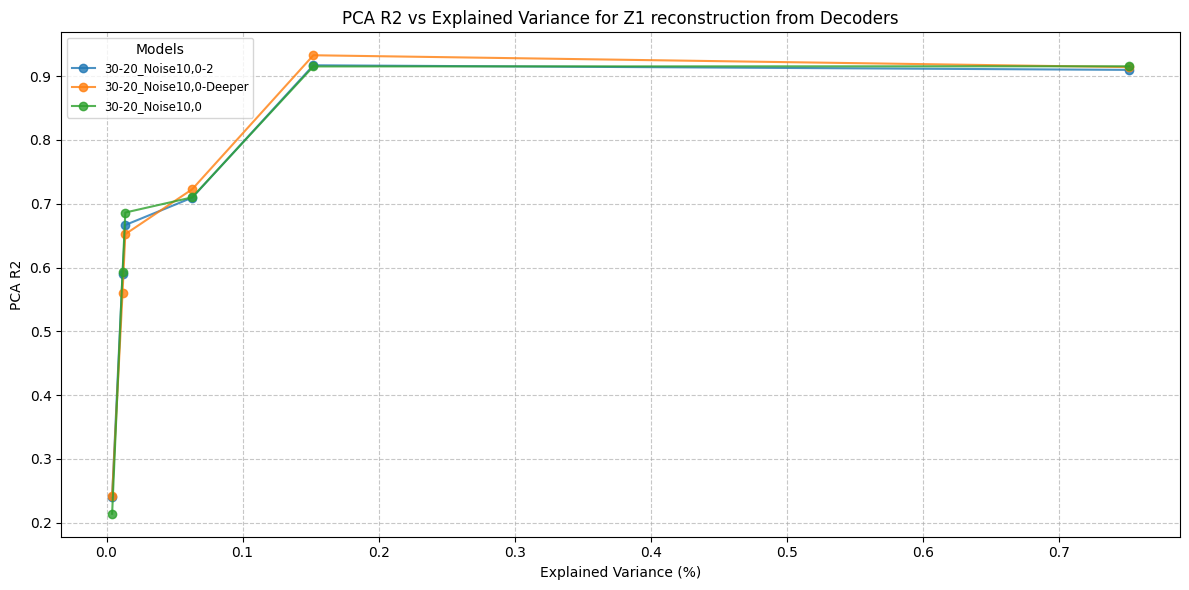

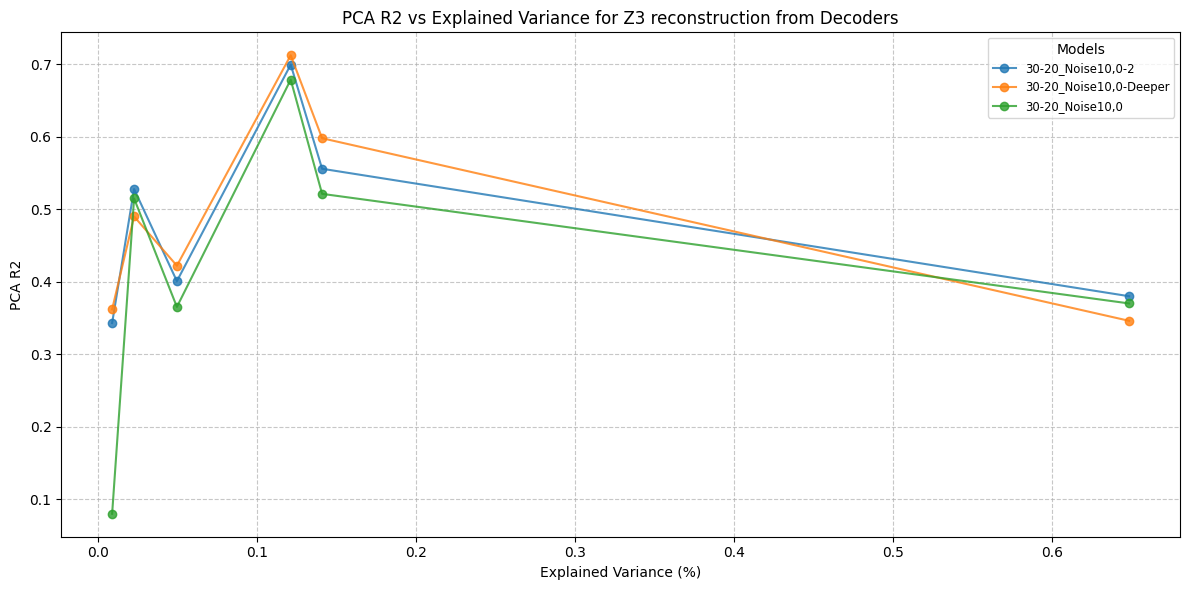

In [18]:
plot_pca_r2_and_variance(
    data=filtered_data,
    r2_col="PCA R2 Z1 PC",
    variance_col="Varianzce Explained Z1",
    title="PCA R2 vs Explained Variance for Z1 reconstruction from Decoders"
)
plot_pca_r2_and_variance(
    data=filtered_data,
    r2_col="PCA R2 Z3 PC",
    variance_col="Varianzce Explained Z3",
    title="PCA R2 vs Explained Variance for Z3 reconstruction from Decoders"
)